## Importy

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import json

## Nacteni ze souboru 

In [30]:
with open("data/planets.json", "r") as f:
    planety = json.load(f)

for nazev, p in planety.items():
    p["position"] = np.array(p["position"], dtype=float)
    p["velocity"] = np.array(p["velocity"], dtype=float)

for nazev, p in planety.items():
    print(f"{nazev}: hmotnost={p['mass']}")

Sun: hmotnost=1.989e+30
Mercury: hmotnost=3.301e+23
Venus: hmotnost=4.867e+24
Earth: hmotnost=5.972e+24
Mars: hmotnost=6.417e+23
Jupiter: hmotnost=1.898e+27
Saturn: hmotnost=5.683e+26
Uranus: hmotnost=8.681e+25
Neptune: hmotnost=1.024e+26


## Fyzika - vypocet

In [ ]:
G = 6.67430e-11
def vypocti_zrychleni(planety):
    zrychleni = {nazev: np.array([0.0, 0.0]) for nazev in planety}

    for nazev_i, p_i in planety.items():
        for nazev_j, p_j in planety.items():
            if nazev_i == nazev_j:
                continue

            rozdil = p_j["position"] - p_i["position"]
            r = np.linalg.norm(rozdil)
            velikost = G * p_j["mass"] * p_i["mass"] / r**2
            sila = velikost * (rozdil / r)
            zrychleni[nazev_i] += sila / p_i["mass"]
    return zrychleni

## Simulace pohybu v case 

In [32]:
dt = 60 * 60 * 24
pocet_kroku = 365
historie = {nazev: [] for nazev in planety}

for krok in range(pocet_kroku):
    zrychleni = vypocti_zrychleni(planety)

    for nazev, p in planety.items():
        p["velocity"] += zrychleni[nazev] * dt
        p["position"] += p["velocity"] * dt
        historie[nazev].append(p["position"].copy())

print("Simulace hotova!")

Simulace hotova!


## Vykresleni trajektorie

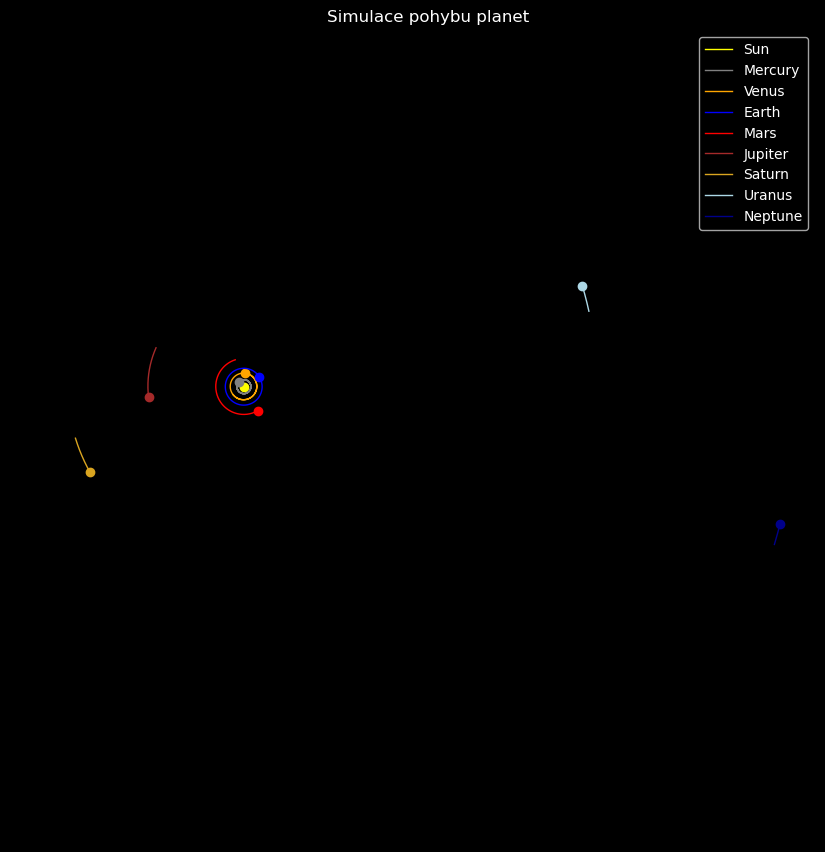

In [ ]:
barvy = {
    "Sun": "yellow",
    "Mercury": "gray",
    "Venus": "orange",
    "Earth": "blue",
    "Mars": "red",
    "Jupiter": "brown",
    "Saturn": "goldenrod",
    "Uranus": "lightblue",
    "Neptune": "darkblue"
}

plt.figure(figsize=(10, 10), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

for nazev, p in planety.items():
    body = np.array(historie[nazev])
    barva = barvy.get(nazev)

    plt.plot(body[:, 0], body[:, 1], color=barva, linewidth=1, label=nazev)

    plt.plot(body[-1, 0], body[-1, 1], "o", color=barva, markersize=6)

plt.legend(facecolor="black", labelcolor="white")
plt.title("Simulace pohybu planet", color="white")
plt.axis("equal")
plt.show()